## SECTION 1 — Load Clean Data

**Why:** Always load from the saved clean file, never re-run preprocessing. This guarantees notebook 03 always uses exactly the same data.

In [1]:
# Cell 1 — Load clean data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../outputs/clean_data.csv')

print("Clean data loaded.")
print("Shape:", df.shape)
print("Students:", df['user_id'].nunique())
print("Skills:", df['skill_name'].nunique())
print("Sample:")

Clean data loaded.
Shape: (294418, 9)
Students: 3053
Skills: 92
Sample:


## SECTION 2 — Check Data Format for pyBKT

**Why:** pyBKT expects specific column names. We verify our data matches before fitting.

Required columns:
- `user_id` → identifies the student
- `skill_name` → identifies the skill
- `correct` → 0 or 1, the student's response

In [2]:
# Cell 2 — Verify data format
print("Required columns present:")
required = ['user_id', 'skill_name', 'correct']
for col in required:
    print(f"  {col}: {'YES' if col in df.columns else 'MISSING'}")

print("\ncorrect column values (should be only 0 and 1):")
print(df['correct'].value_counts())

print("\nSample student sequence (first student, first skill):")
first_student = df['user_id'].iloc[0]
first_skill = df[df['user_id'] == first_student]['skill_name'].iloc[0]
sample = df[(df['user_id'] == first_student) &
            (df['skill_name'] == first_skill)][
    ['user_id', 'skill_name', 'correct', 'opportunity']
]
print(sample)

Required columns present:
  user_id: YES
  skill_name: YES
  correct: YES

correct column values (should be only 0 and 1):
correct
1    194415
0    100003
Name: count, dtype: int64

Sample student sequence (first student, first skill):
    user_id    skill_name  correct  opportunity
0        14  Circle Graph        0            1
2        14  Circle Graph        1            2
4        14  Circle Graph        0            3
6        14  Circle Graph        0            4
8        14  Circle Graph        0            5
10       14  Circle Graph        0            6
12       14  Circle Graph        0            7
15       14  Circle Graph        0            8
18       14  Circle Graph        1            9
20       14  Circle Graph        0           10
23       14  Circle Graph        1           11
25       14  Circle Graph        0           12


## SECTION 3 — Fit BKT Model

**Why:** pyBKT fits one BKT model per skill using Expectation-Maximization (EM) to estimate 4 parameters (L0, T, S, G) that best explain each skill's response patterns.

You do NOT fit one model per student — you fit one model per skill, then use it to estimate each individual student's mastery.

**Thesis note:** "BKT parameters were estimated using the Expectation-Maximization algorithm implemented in the pyBKT library, with 5 random restarts to avoid local optima."

In [3]:
# Cell 3 — Fit BKT model
import importlib
from pyBKT.fit import EM_fit, predict_onestep
importlib.reload(EM_fit)
importlib.reload(predict_onestep)
from pyBKT.models import Model

# seed=42 ensures reproducible results
# num_fits=5 tries 5 random starting points and picks the best
model = Model(seed=42, num_fits=1, parallel=False)

print("Fitting BKT model on all skills...")
print("This may take 1-3 minutes...")

# skills='.*' is a regex matching all skill names in the skill_name column
model.fit(data=df, skills='.*')
fit_params = model.params()
if not np.isfinite(fit_params['value']).all():
    raise RuntimeError('BKT fitting produced non-finite parameters')

# Keep wildcard selection for predict(); pyBKT otherwise joins skill names
# into an unescaped regex and can omit names containing +, *, or parentheses.
model.skills = '.*'
print("\nBKT model fitted successfully with finite parameters!")

Fitting BKT model on all skills...
This may take 1-3 minutes...

BKT model fitted successfully with finite parameters!


## SECTION 4 — Inspect Fitted Parameters

**Why:** The 4 parameters per skill are scientifically meaningful. They tell us about the difficulty and learnability of each skill.

| Parameter | Low value means | High value means |
|---|---|---|
| prior (L0) | Most students start not knowing it | Most students already know it |
| learns (T) | Hard to learn — needs many attempts | Easy to learn — few attempts needed |
| slips (S) | Students rarely make careless errors | Many careless errors |
| guesses (G) | Hard to guess correctly | Easy to guess correctly |

In [4]:
# Cell 4 — View fitted parameters per skill
params = model.params()
print("BKT parameters per skill:")
print(params)

BKT parameters per skill:
                                              value
skill                       param   class          
Percent Of                  prior   default 0.67436
                            learns  default 0.09925
                            guesses default 0.07655
                            slips   default 0.28591
                            forgets default 0.00000
...                                             ...
Finding Slope From Equation prior   default 0.35888
                            learns  default 0.32274
                            guesses default 1.00000
                            slips   default 0.30889
                            forgets default 0.00000

[460 rows x 1 columns]


Plot columns: ['skill', 'forgets', 'guesses', 'learns', 'prior', 'slips']


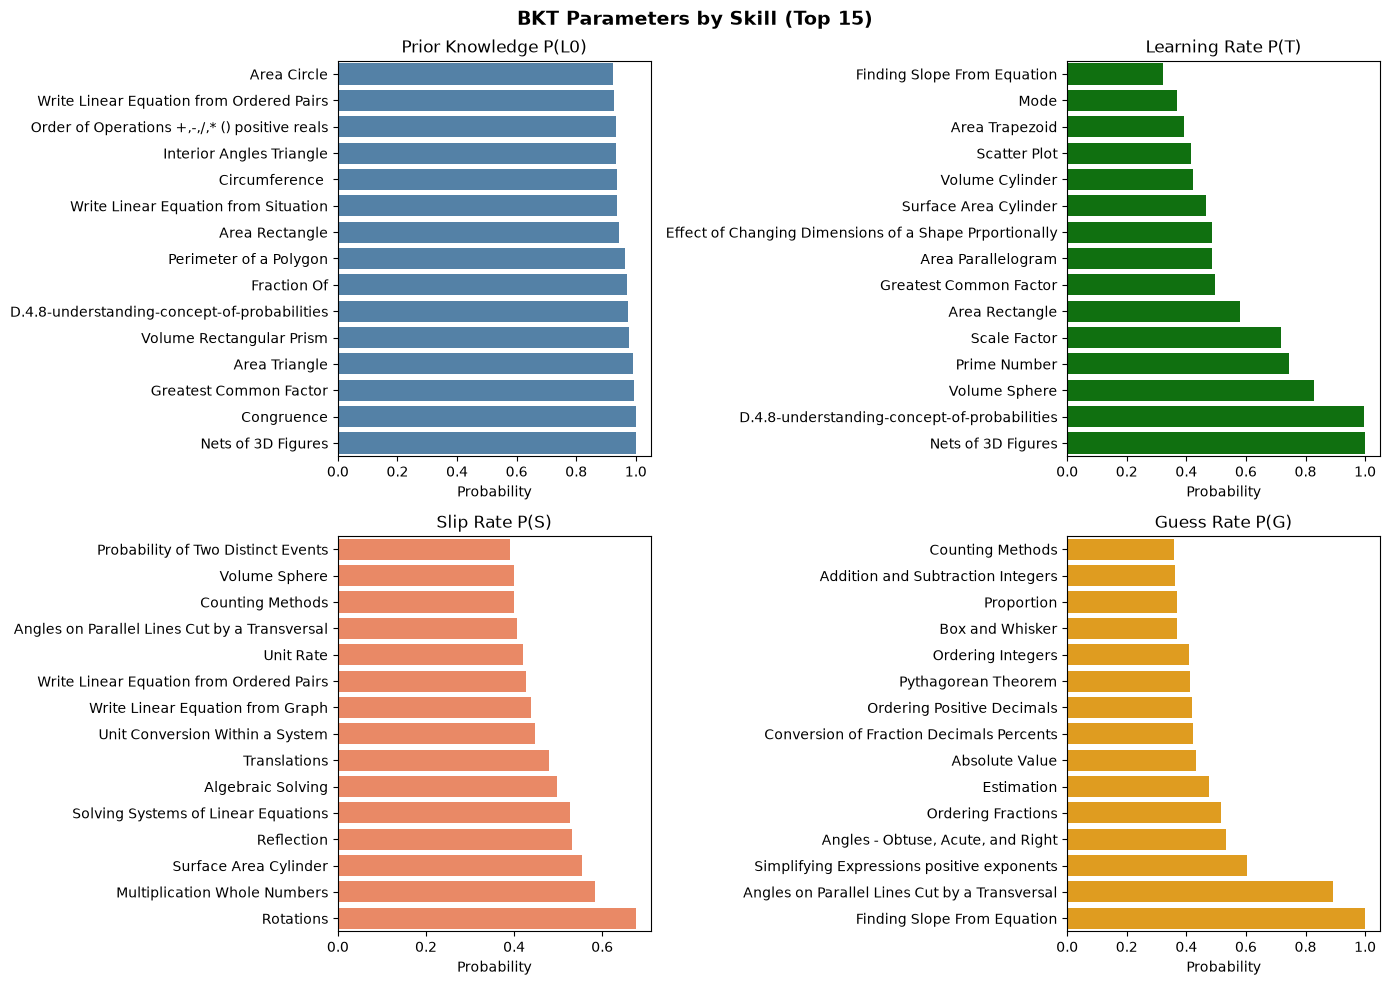

Parameter chart saved!


In [5]:
# Cell 5 — Visualize parameters for top 15 skills
# model.params() is long-form: skill, param, class, value. Pivot it so
# prior/learns/slips/guesses become numeric columns that can be plotted.
params_plot = (
    params.reset_index()
    .pivot_table(index='skill', columns='param', values='value', aggfunc='first')
    .reset_index()
)
metrics = ['prior', 'learns', 'slips', 'guesses']
missing_metrics = [metric for metric in metrics if metric not in params_plot.columns]
if missing_metrics:
    raise RuntimeError(f'Missing BKT parameter columns: {missing_metrics}')
if not np.isfinite(params_plot[metrics].to_numpy()).all():
    raise RuntimeError('Cannot plot non-finite BKT parameters')

print('Plot columns:', params_plot.columns.tolist())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles  = ['Prior Knowledge P(L0)', 'Learning Rate P(T)',
           'Slip Rate P(S)', 'Guess Rate P(G)']
colors  = ['steelblue', 'green', 'coral', 'orange']

for ax, metric, title, color in zip(axes.flatten(), metrics, titles, colors):
    top = params_plot.nlargest(15, metric).sort_values(metric)
    sns.barplot(data=top, x=metric, y='skill', color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Probability')
    ax.set_ylabel('')

plt.suptitle('BKT Parameters by Skill (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/bkt_parameters.png', dpi=150)
plt.show()
print("Parameter chart saved!")

## SECTION 5 — Generate Mastery Estimates

**Why:** After fitting, we use the model to calculate the final mastery probability for each student on each skill they practiced.

`predict()` returns two new columns:
- `correct_predictions` — probability of answering the NEXT question correctly (used for evaluation in notebook 04)
- `state_predictions` — probability of being in the "learned" state at this point (the mastery estimate)

In [6]:
# Cell 6 — Generate predictions
model.skills = '.*'
print("Generating mastery predictions...")
predictions = model.predict(data=df)
for column in ['correct_predictions', 'state_predictions']:
    if not np.isfinite(predictions[column]).all():
        raise RuntimeError(f'{column} contains non-finite values')

print("Predictions shape:", predictions.shape)
print("Prediction columns:", predictions.columns.tolist())
print("\nSample predictions:")
print(predictions.head(10))

Generating mastery predictions...
Predictions shape: (294418, 11)
Prediction columns: ['user_id', 'skill_name', 'correct', 'opportunity', 'hint_count', 'attempt_count', 'order_id', 'original', 'ms_first_response', 'correct_predictions', 'state_predictions']

Sample predictions:
   user_id    skill_name  correct  opportunity  hint_count  attempt_count  \
0       14  Circle Graph        0            1           2              1   
1       14    Percent Of        0            1           2              1   
2       14  Circle Graph        1            2           0              1   
3       14    Percent Of        1            2           0              1   
4       14  Circle Graph        0            3           2              1   
5       14    Percent Of        0            3           2              1   
6       14  Circle Graph        0            4           2              1   
7       14    Percent Of        0            4           2              1   
8       14  Circle Graph    

## SECTION 6 — Extract Final Mastery Per Student Per Skill

**Why:** `predict()` gives mastery at every timestep. We only want the FINAL mastery estimate — the last value after all interactions. This represents where the student ended up.

In [7]:
# Cell 7 — Extract final mastery estimate per student per skill
mastery = predictions.groupby(
    ['user_id', 'skill_name']
).agg(
    mastery_prob=('state_predictions', 'last'),
    n_opportunities=('opportunity', 'max'),
    correct_rate=('correct', 'mean')
).reset_index()

print("Mastery estimates shape:", mastery.shape)
print(f"\nTotal student-skill pairs: {len(mastery)}")
print("\nSample mastery estimates:")
print(mastery.head(10))

print("\nMastery probability statistics:")
print(mastery['mastery_prob'].describe())

Mastery estimates shape: (37019, 5)

Total student-skill pairs: 37019

Sample mastery estimates:
   user_id                            skill_name  mastery_prob  \
0       14                          Circle Graph       0.62124   
1       14                  Equivalent Fractions       0.92789   
2       14                      Finding Percents       0.20624   
3       14                                Median       0.12635   
4       14                            Percent Of       0.33831   
5       14                            Proportion       0.27010   
6       14                                 Range       0.96618   
7    21825                                  Mean       0.99603   
8    21825                                Median       0.53607   
9    21825  Multiplication and Division Integers       1.00000   

   n_opportunities  correct_rate  
0               12       0.25000  
1                6       0.33333  
2                2       0.00000  
3                4       0.00000  
4

## SECTION 7 — Visualize Mastery Distribution

**Why:** We expect a spread of mastery values — some students mastered skills, others did not. If all values cluster near 0.5, something is wrong.

**Mastery threshold of 0.8:** Standard in BKT research — if P(mastered) >= 0.8, the student has mastered the skill.

**Thesis note:** "Following standard practice in BKT research, a mastery threshold of 0.8 was applied to classify knowledge component mastery."

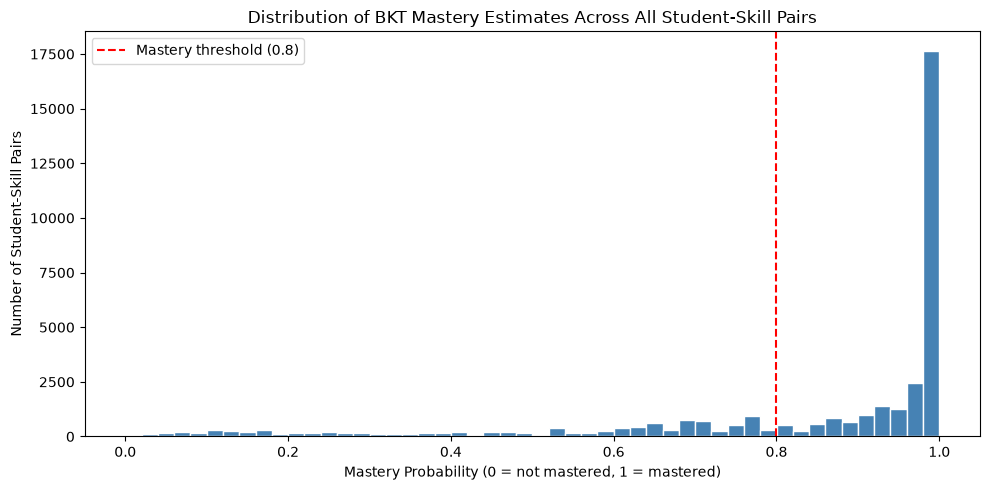


Student-skill pairs above mastery threshold (0.8):
  26593 out of 37019 (71.8%)


In [8]:
# Cell 8 — Distribution of mastery probabilities
plt.figure(figsize=(10, 5))
plt.hist(mastery['mastery_prob'], bins=50,
         color='steelblue', edgecolor='white')
plt.title('Distribution of BKT Mastery Estimates Across All Student-Skill Pairs')
plt.xlabel('Mastery Probability (0 = not mastered, 1 = mastered)')
plt.ylabel('Number of Student-Skill Pairs')
plt.axvline(x=0.8, color='red', linestyle='--',
            label='Mastery threshold (0.8)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/mastery_distribution.png', dpi=150)
plt.show()

threshold = 0.8
mastered = (mastery['mastery_prob'] >= threshold).sum()
total = len(mastery)
print(f"\nStudent-skill pairs above mastery threshold ({threshold}):")
print(f"  {mastered} out of {total} ({round(mastered/total*100, 1)}%)")

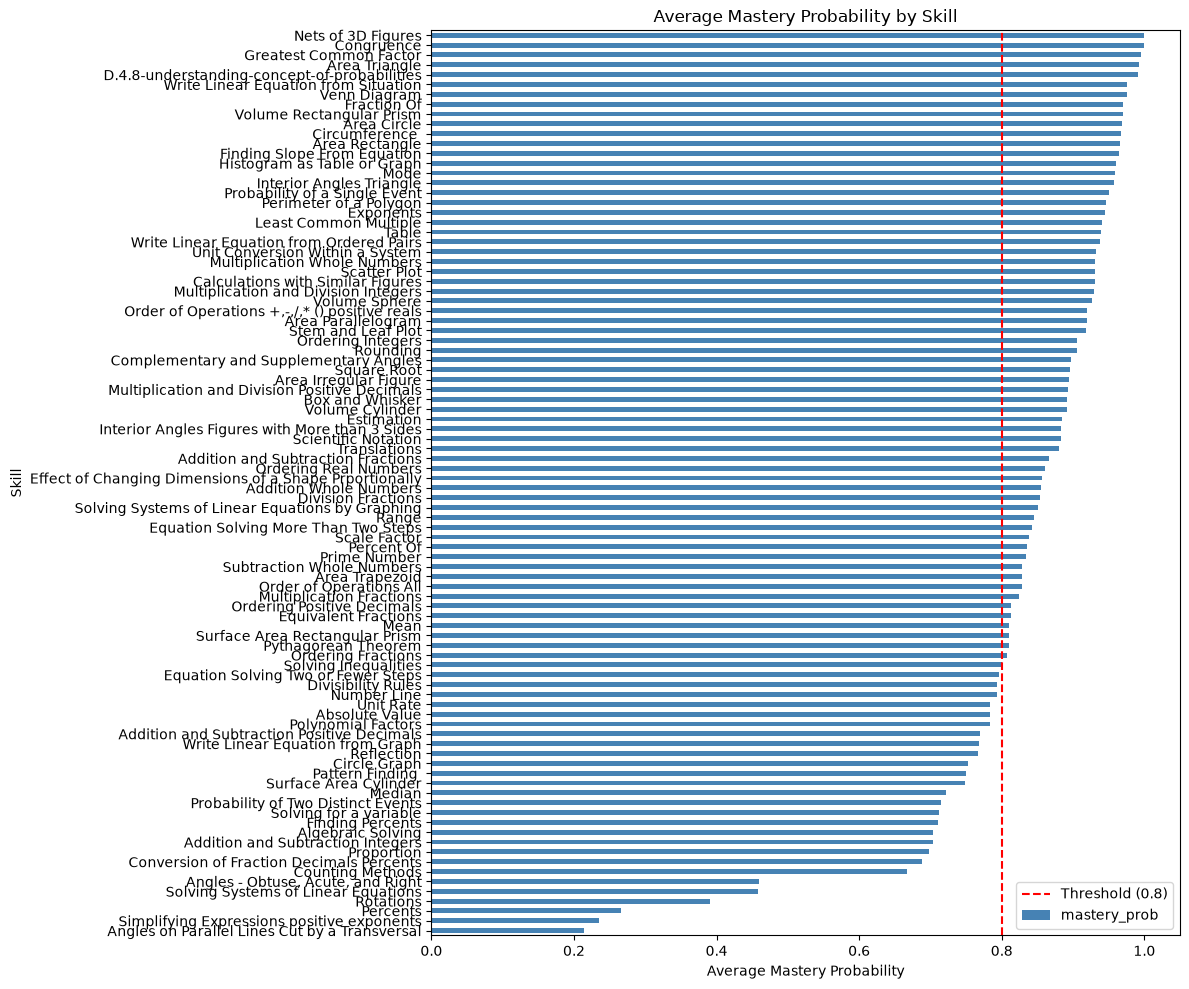

In [9]:
# Cell 9 — Average mastery per skill
skill_mastery = mastery.groupby('skill_name')['mastery_prob'].mean().sort_values()

plt.figure(figsize=(12, 10))
skill_mastery.plot(kind='barh', color='steelblue')
plt.title('Average Mastery Probability by Skill')
plt.xlabel('Average Mastery Probability')
plt.ylabel('Skill')
plt.axvline(x=0.8, color='red', linestyle='--', label='Threshold (0.8)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/mastery_by_skill.png', dpi=150)
plt.show()

## SECTION 8 — Save Mastery Estimates

**Why:** This file is the bridge to everything after. Notebook 04 (evaluation) uses `correct_predictions` to measure accuracy. Notebook 05 (recommendations) uses `mastery_prob` to identify knowledge gaps.

In [10]:
# Cell 10 — Save mastery estimates
output_path = '../outputs/mastery_estimates.csv'
mastery.to_csv(output_path, index=False)

print(f"Mastery estimates saved to: {output_path}")
print(f"Shape: {mastery.shape}")
print("\nColumns saved:")
for col in mastery.columns:
    print(f"  - {col}")
print("\nDone! Ready for notebook 04 — Evaluation.")

Mastery estimates saved to: ../outputs/mastery_estimates.csv
Shape: (37019, 5)

Columns saved:
  - user_id
  - skill_name
  - mastery_prob
  - n_opportunities
  - correct_rate

Done! Ready for notebook 04 — Evaluation.
